# Part 1: Acne Detection on ACNE04

This notebook trains and compares **three object detectors** on the ACNE04 dataset:

| Model | Family | Anchors |
|---|---|---|
| **YOLOv8** | One-stage CNN | Anchor-free |
| **Faster R-CNN + ResNet50-FPN** | Two-stage CNN | Anchor-based |
| **RT-DETR** (DINO family) | One-stage Transformer | Anchor-free queries |

Run end-to-end on Colab (T4 GPU) in ~3 hours.


## 0. Setup

Link: https://github.com/nprakash1/acne_yang_project/tree/main/part1_detection

In [1]:
# Auto-detect how the project got into this Colab runtime.
# Supports three workflows -- you don't have to edit anything:
#   (1) git clone   - set GITHUB_URL below to a public repo URL
#   (2) zip upload  - drag acne_yang_project.zip into Colab's file pane
#   (3) Drive copy  - put the unzipped folder anywhere in your Drive
import os, glob, subprocess

GITHUB_URL = 'https://github.com/nprakash1/acne_yang_project.git'
PROJECT_DIR = 'acne_yang_project'

def _is_project_root(p):
    return os.path.isdir(os.path.join(p, 'part1_detection')) and \
           os.path.isfile(os.path.join(p, 'requirements.txt'))

# Already at project root?
if _is_project_root('.'):
    print('[setup] already at project root')
elif os.path.isdir(PROJECT_DIR) and _is_project_root(PROJECT_DIR):
    %cd $PROJECT_DIR
    print(f'[setup] cd into ./{PROJECT_DIR}')
else:
    zips = glob.glob('/content/*.zip') + glob.glob('./*.zip')
    drive_hits = glob.glob('/content/drive/MyDrive/**/part1_detection', recursive=True)
    if zips:
        z = zips[0]
        print(f'[setup] unzipping {z}')
        subprocess.check_call(['unzip', '-q', '-o', z, '-d', '/content/_extracted'])
        roots = [r for r, _, _ in os.walk('/content/_extracted') if _is_project_root(r)]
        assert roots, 'zip did not contain a project root (part1_detection/ + requirements.txt)'
        %cd $roots[0]
    elif drive_hits:
        root = os.path.dirname(drive_hits[0])
        print(f'[setup] using project from Drive: {root}')
        %cd $root
    elif GITHUB_URL:
        print(f'[setup] cloning {GITHUB_URL}')
        subprocess.check_call(['git', 'clone', GITHUB_URL])
        %cd $PROJECT_DIR
    else:
        raise RuntimeError(
            'No project source found. Either:\n'
            ' - set GITHUB_URL above to your repo, or\n'
            ' - drag acne_yang_project.zip into the Colab file pane and re-run, or\n'
            ' - mount Drive (next cell) with the project folder inside MyDrive.'
        )

print('[setup] cwd =', os.getcwd())
!pip install -q -r requirements.txt
print('[setup] dependencies installed')

[setup] cloning https://github.com/nprakash1/acne_yang_project.git
/content/acne_yang_project
[setup] cwd = /content/acne_yang_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 160.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 149.9 MB/s eta 0:00:00
[setup] dependencies installed


In [2]:
# Mount drive (optional, for persisting weights)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

Mounted at /content/drive


## 1. Download ACNE04

We pull the dataset from Roboflow Universe in **both YOLOv8 and COCO formats** so the same images back all three models. You need a free Roboflow API key from https://app.roboflow.com/settings/api.

In [3]:
import os
os.environ['ROBOFLOW_API_KEY'] = 'c1orEQIdQdZYPwUiFe2I'

from part1_detection.data import download_acne04, build_yaml
yolo_root = download_acne04(out_dir='data/acne04', fmt='yolov8')
coco_root = download_acne04(out_dir='data/acne04', fmt='coco')
yaml_path = build_yaml(yolo_root, 'data/acne04.yaml')
print('YOLO root:', yolo_root)
print('COCO root:', coco_root)
print('YAML:', yaml_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/yolov8 in yolov8:: 100%|██████████| 6808/6808 [00:00<00:00, 9175.99it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/coco in coco:: 100%|██████████| 3406/3406 [00:00<00:00, 7005.73it/s]


YOLO root: /content/acne_yang_project/data/acne04/yolov8
COCO root: /content/acne_yang_project/data/acne04/coco
YAML: /content/acne_yang_project/data/acne04.yaml


## 2. Train YOLOv8

In [4]:
from part1_detection.train_ultralytics import train_yolo
# imgsz bumped to 1024 -- acne lesions are tiny (5-30 px); larger input is the single biggest small-object lever
yolo_results = train_yolo(data=str(yaml_path), epochs=150, imgsz=1024, batch=12)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

## 3. Train Faster R-CNN (ResNet50-FPN)

In [5]:
from part1_detection.train_faster_rcnn import train as train_frcnn
# longer schedule + smaller LR to match the bigger min/max image size and tighter anchors
frcnn_model = train_frcnn(coco_root=str(coco_root), epochs=40, batch_size=2, lr=2e-3)

train images: 2973  |  val images: 283
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 202MB/s]


  epoch 1 step 0/744 loss 1.7131 (1.7131 avg)
  epoch 1 step 20/744 loss 0.1450 (0.6758 avg)
  epoch 1 step 40/744 loss 0.2993 (0.4591 avg)
  epoch 1 step 60/744 loss 0.0602 (0.3839 avg)
  epoch 1 step 80/744 loss 0.1881 (0.3402 avg)
  epoch 1 step 100/744 loss 0.0843 (0.3070 avg)
  epoch 1 step 120/744 loss 0.1397 (0.2923 avg)
  epoch 1 step 140/744 loss 0.1210 (0.2847 avg)
  epoch 1 step 160/744 loss 0.0560 (0.2697 avg)
  epoch 1 step 180/744 loss 0.2284 (0.2706 avg)
  epoch 1 step 200/744 loss 0.2891 (0.2667 avg)
  epoch 1 step 220/744 loss 0.2420 (0.2585 avg)
  epoch 1 step 240/744 loss 0.2788 (0.2544 avg)
  epoch 1 step 260/744 loss 0.3045 (0.2540 avg)
  epoch 1 step 280/744 loss 0.0590 (0.2506 avg)
  epoch 1 step 300/744 loss 0.2388 (0.2491 avg)
  epoch 1 step 320/744 loss 0.1795 (0.2434 avg)
  epoch 1 step 340/744 loss 0.1574 (0.2405 avg)
  epoch 1 step 360/744 loss 0.4797 (0.2404 avg)
  epoch 1 step 380/744 loss 0.0292 (0.2405 avg)
  epoch 1 step 400/744 loss 0.1004 (0.2389 avg

## 4. Train RT-DETR (DINO family)

In [6]:
from part1_detection.train_ultralytics import train_rtdetr
# RT-DETR also benefits from larger input; batch shrunk to fit the same VRAM budget
rtdetr_results = train_rtdetr(data=str(yaml_path), epochs=120, imgsz=1024, batch=6)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/80      6.54G      1.808     0.3335     0.6748         52        640: 100% ━━━━━━━━━━━━ 40/40 1.6it/s 25.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9s/it 3.9s
                   all         22       1185      0.155      0.166     0.0569     0.0116

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/80      6.93G      1.208      0.393     0.2246        453        640: 0% ──────────── 0/40  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/80      6.94G      1.237     0.3959     0.2696         49        640: 100% ━━━━━━━━━━━━ 40/40 3.0it/s 13.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 9.5it/s 0.2s
                   all         22       1185      0.301      0.313       0.18     0.0388

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/80      6.94G      1.113      0.445     0.2079        408        640: 0% ──────────── 0/40  0.3s

...

      60/80      6.94G     0.7651     0.4518     0.1326         63        640: 100% ━━━━━━━━━━━━ 40/40 3.0it/s 13.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 9.4it/s 0.2s
                   all         22       1185      0.335      0.361      0.205     0.0438

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      61/80      6.94G     0.8633     0.4396     0.1397        440        640: 0% ──────────── 0/40  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      61/80      6.94G     0.7525     0.4519     0.1285         53        640: 100% ━━━━━━━━━━━━ 40/40 3.1it/s 13.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 9.2it/s 0.2s
                   all         22       1185      0.359      0.366      0.227     0.0498

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      62/80      6.94G     0.8202     0.4423      0.148        362        640: 0% ──────────── 0/40  0.3s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      62/80      6.94G      0.738     0.4545     0.1294         52        640: 100% ━━━━━━━━━━━━ 40/40 3.1it/s 13.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 9.3it/s 0.2s
                   all         22       1185      0.334      0.387      0.226     0.0488
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 32, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

62 epochs completed in 0.259 hours.
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/last.pt, 66.2MB
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt, 66.2MB

Validating /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+c

## 5. Unified Evaluation (mAP / P / R / IoU)

All three models scored with the **same pycocotools COCOeval** for an apples-to-apples comparison.

In [10]:
from part1_detection.evaluate import evaluate_model
import pandas as pd

metrics = {}
metrics['YOLOv8'] = evaluate_model('yolo', '/content/acne_yang_project/runs/detect/outputs/yolov8/acne/weights/best.pt', str(coco_root))
metrics['Faster R-CNN'] = evaluate_model('frcnn', 'outputs/faster_rcnn/best.pth', str(coco_root))
metrics['RT-DETR']     = evaluate_model('rtdetr', '/content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt', str(coco_root))

df = pd.DataFrame(metrics).T[['mAP@0.5', 'mAP@0.5:0.95', 'precision@0.5', 'recall@0.5', 'mean_iou']]
df

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.43s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.24s).
Accumulating evaluation results...
DONE (t=0.09s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

,mAP@0.5,mAP@0.5:0.95,precision@0.5,recall@0.5,mean_iou
YOLOv8,0.011601,0.002525,0.367483,0.189983,0.631916
Faster R-CNN,0.005950,0.001111,0.124870,0.413356,0.609686
RT-DETR,0.037204,0.007967,0.237884,0.432355,0.630056


## 6. Side-by-side bbox visualizations

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
saved outputs/viz/predictions_test.png


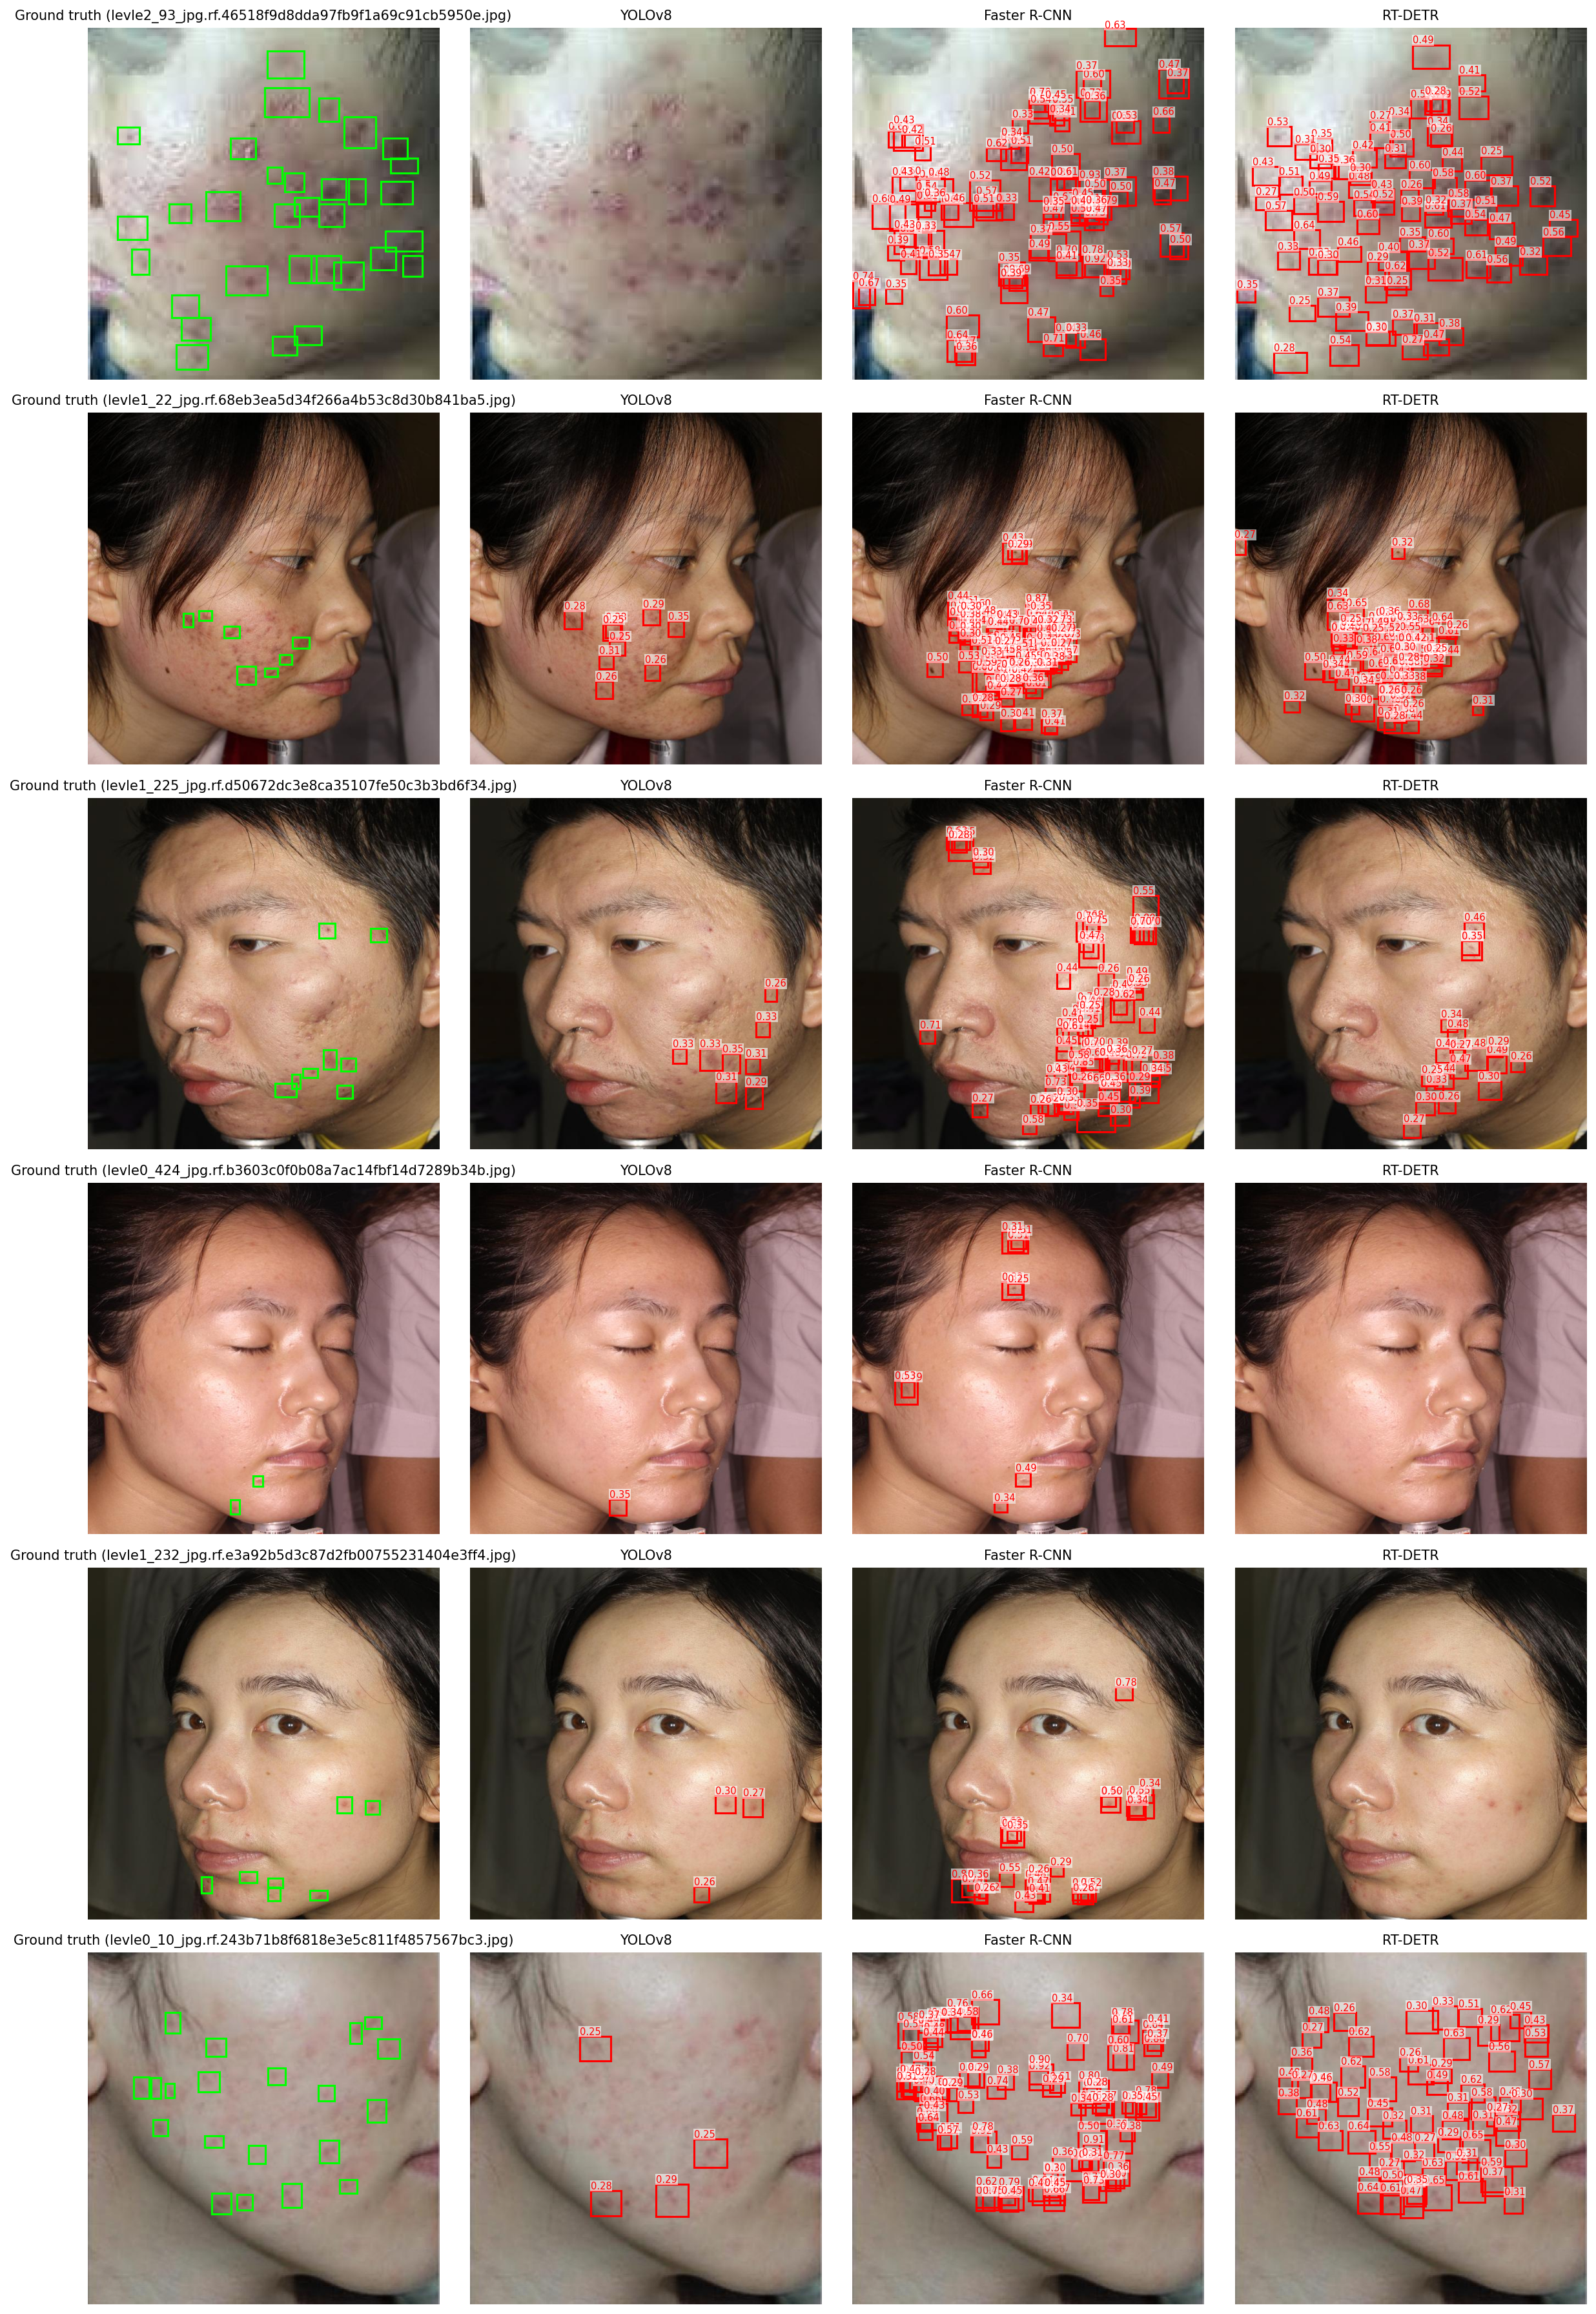

In [12]:
from part1_detection.visualize import visualize_predictions
from IPython.display import Image as IPyImage

out = visualize_predictions(
    models={
        'YOLOv8':       {'kind': 'yolo',   'weights': '/content/acne_yang_project/runs/detect/outputs/yolov8/acne/weights/best.pt'},
        'Faster R-CNN': {'kind': 'frcnn',  'weights': 'outputs/faster_rcnn/best.pth'},
        'RT-DETR':      {'kind': 'rtdetr', 'weights': '/content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt'},
    },
    coco_root=str(coco_root),
    n_images=6,
)
IPyImage(filename=str(out))

In [13]:
# === Save all training artifacts to Google Drive ===
import os, shutil, datetime
DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

# (optional) keep a timestamped snapshot so you don't overwrite earlier runs
SNAPSHOT = os.path.join(DRIVE_ROOT, datetime.datetime.now().strftime('snap_%Y%m%d_%H%M'))
os.makedirs(SNAPSHOT, exist_ok=True)

for src in ['outputs', 'runs']:
    if os.path.isdir(src):
        dst_latest   = os.path.join(DRIVE_ROOT, src)          # always-current copy
        dst_snapshot = os.path.join(SNAPSHOT,   src)          # frozen copy
        print(f'[save] {src}/ -> {dst_latest}/ (+ snapshot)')
        shutil.copytree(src, dst_latest,   dirs_exist_ok=True)
        shutil.copytree(src, dst_snapshot, dirs_exist_ok=True)
    else:
        print(f'[skip] {src}/ does not exist')

print('\n[save] done. Drive contents:')
!ls -lh "$DRIVE_ROOT"
print('\n[save] snapshot saved at:', SNAPSHOT)


[save] outputs/ -> /content/drive/MyDrive/acne_yang_project_runs/outputs/ (+ snapshot)
[save] runs/ -> /content/drive/MyDrive/acne_yang_project_runs/runs/ (+ snapshot)

[save] done. Drive contents:
total 12K
drwx------ 5 root root 4.0K May 12 00:52 outputs
drwx------ 3 root root 4.0K May 11 23:02 runs
drwx------ 4 root root 4.0K May 12 01:04 snap_20260512_0104

[save] snapshot saved at: /content/drive/MyDrive/acne_yang_project_runs/snap_20260512_0104
